<a href="https://colab.research.google.com/github/Himanshu0518/Credit-Card-Fraud-Analysis/blob/main/notebooks/credit_card_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [69]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import  train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import warnings
warnings.filterwarnings('ignore')

In [41]:
df = pd.read_csv("/content/CreditCardData.csv")
df.head()

,Transaction ID,Date,Day of Week,Time,Type of Card,Entry Mode,Amount,Type of Transaction,Merchant Group,Country of Transaction,Shipping Address,Country of Residence,Gender,Age,Bank,Fraud
0,#3577 209,14-Oct-20,Wednesday,19,Visa,Tap,£5,POS,Entertainment,United Kingdom,United Kingdom,United Kingdom,M,25.2,RBS,0
1,#3039 221,14-Oct-20,Wednesday,17,MasterCard,PIN,£288,POS,Services,USA,USA,USA,F,49.6,Lloyds,0
2,#2694 780,14-Oct-20,Wednesday,14,Visa,Tap,£5,POS,Restaurant,India,India,India,F,42.2,Barclays,0
3,#2640 960,13-Oct-20,Tuesday,14,Visa,Tap,£28,POS,Entertainment,United Kingdom,India,United Kingdom,F,51.0,Barclays,0
4,#2771 031,13-Oct-20,Tuesday,23,Visa,CVC,£91,Online,Electronics,USA,USA,United Kingdom,M,38.0,Halifax,1


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Transaction ID          100000 non-null  object 
 1   Date                    100000 non-null  object 
 2   Day of Week             100000 non-null  object 
 3   Time                    100000 non-null  int64  
 4   Type of Card            100000 non-null  object 
 5   Entry Mode              100000 non-null  object 
 6   Amount                  99994 non-null   object 
 7   Type of Transaction     100000 non-null  object 
 8   Merchant Group          99990 non-null   object 
 9   Country of Transaction  100000 non-null  object 
 10  Shipping Address        99995 non-null   object 
 11  Country of Residence    100000 non-null  object 
 12  Gender                  99996 non-null   object 
 13  Age                     100000 non-null  float64
 14  Bank                 

In [43]:
df.shape

(100000, 16)

In [44]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Day of Week,0
Time,0
Type of Card,0
Entry Mode,0
Amount,6
Type of Transaction,0
Merchant Group,10
Country of Transaction,0


In [45]:
df.dropna(inplace=True)

In [46]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Day of Week,0
Time,0
Type of Card,0
Entry Mode,0
Amount,0
Type of Transaction,0
Merchant Group,0
Country of Transaction,0


In [47]:
df.drop(['Transaction ID','Date'],axis=1,inplace=True)

In [48]:
df.head()

,Day of Week,Time,Type of Card,Entry Mode,Amount,Type of Transaction,Merchant Group,Country of Transaction,Shipping Address,Country of Residence,Gender,Age,Bank,Fraud
0,Wednesday,19,Visa,Tap,£5,POS,Entertainment,United Kingdom,United Kingdom,United Kingdom,M,25.2,RBS,0
1,Wednesday,17,MasterCard,PIN,£288,POS,Services,USA,USA,USA,F,49.6,Lloyds,0
2,Wednesday,14,Visa,Tap,£5,POS,Restaurant,India,India,India,F,42.2,Barclays,0
3,Tuesday,14,Visa,Tap,£28,POS,Entertainment,United Kingdom,India,United Kingdom,F,51.0,Barclays,0
4,Tuesday,23,Visa,CVC,£91,Online,Electronics,USA,USA,United Kingdom,M,38.0,Halifax,1


In [49]:
df['Amount'] = df['Amount'].str.replace('£','')
df['Amount'] = df['Amount'].astype(float)

In [50]:
df.head(2)

,Day of Week,Time,Type of Card,Entry Mode,Amount,Type of Transaction,Merchant Group,Country of Transaction,Shipping Address,Country of Residence,Gender,Age,Bank,Fraud
0,Wednesday,19,Visa,Tap,5.0,POS,Entertainment,United Kingdom,United Kingdom,United Kingdom,M,25.2,RBS,0
1,Wednesday,17,MasterCard,PIN,288.0,POS,Services,USA,USA,USA,F,49.6,Lloyds,0


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99977 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Day of Week             99977 non-null  object 
 1   Time                    99977 non-null  int64  
 2   Type of Card            99977 non-null  object 
 3   Entry Mode              99977 non-null  object 
 4   Amount                  99977 non-null  float64
 5   Type of Transaction     99977 non-null  object 
 6   Merchant Group          99977 non-null  object 
 7   Country of Transaction  99977 non-null  object 
 8   Shipping Address        99977 non-null  object 
 9   Country of Residence    99977 non-null  object 
 10  Gender                  99977 non-null  object 
 11  Age                     99977 non-null  float64
 12  Bank                    99977 non-null  object 
 13  Fraud                   99977 non-null  int64  
dtypes: float64(2), int64(2), object(10)
memory 

In [52]:
df.columns

Index(['Day of Week', 'Time', 'Type of Card', 'Entry Mode', 'Amount',
       'Type of Transaction', 'Merchant Group', 'Country of Transaction',
       'Shipping Address', 'Country of Residence', 'Gender', 'Age', 'Bank',
       'Fraud'],
      dtype='object')

In [53]:
categorical_columns = ['Day of Week','Type of Card','Entry Mode','Type of Transaction','Merchant Group','Country of Transaction','Shipping Address','Country of Residence','Gender','Bank']
numerical_columns = ['Amount','Age','Time']

In [54]:
len(categorical_columns)+len(numerical_columns) == len(df.columns)-1

True

In [55]:
X = df.drop(['Fraud'],axis=1)
Y = df['Fraud']

#EDA and Visualisations

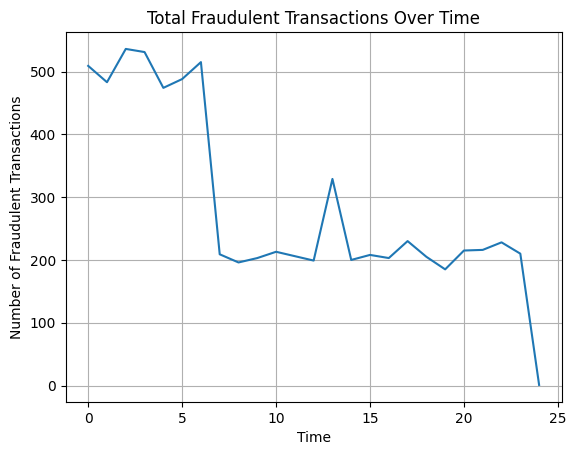

In [56]:
fraud_by_time = df.groupby('Time')['Fraud'].sum().reset_index()
sns.lineplot(x='Time', y='Fraud', data=fraud_by_time)
plt.title('Total Fraudulent Transactions Over Time')
plt.xlabel('Time')
plt.ylabel('Number of Fraudulent Transactions')
plt.grid(True)
plt.show()

### Distribution of Numerical Features

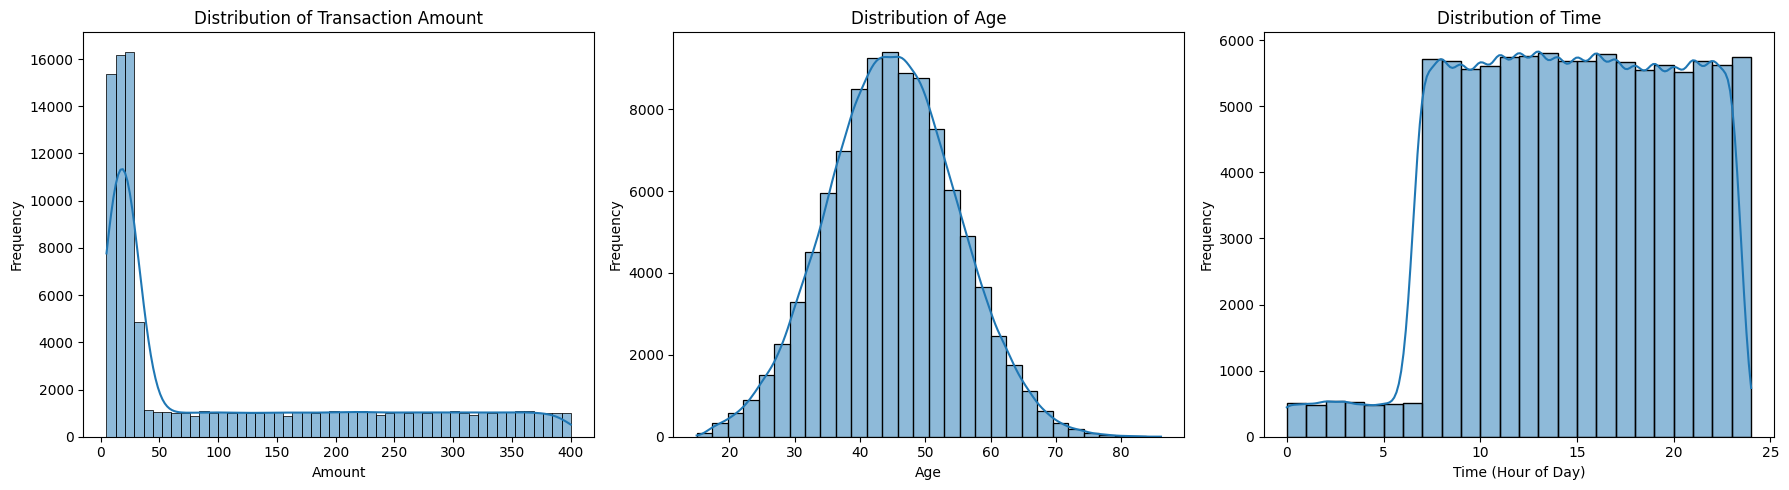

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Amount'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Transaction Amount')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')

sns.histplot(df['Age'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Age')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')

sns.histplot(df['Time'], bins=24, kde=True, ax=axes[2])
axes[2].set_title('Distribution of Time')
axes[2].set_xlabel('Time (Hour of Day)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Distribution of Categorical Features and Fraud Rate

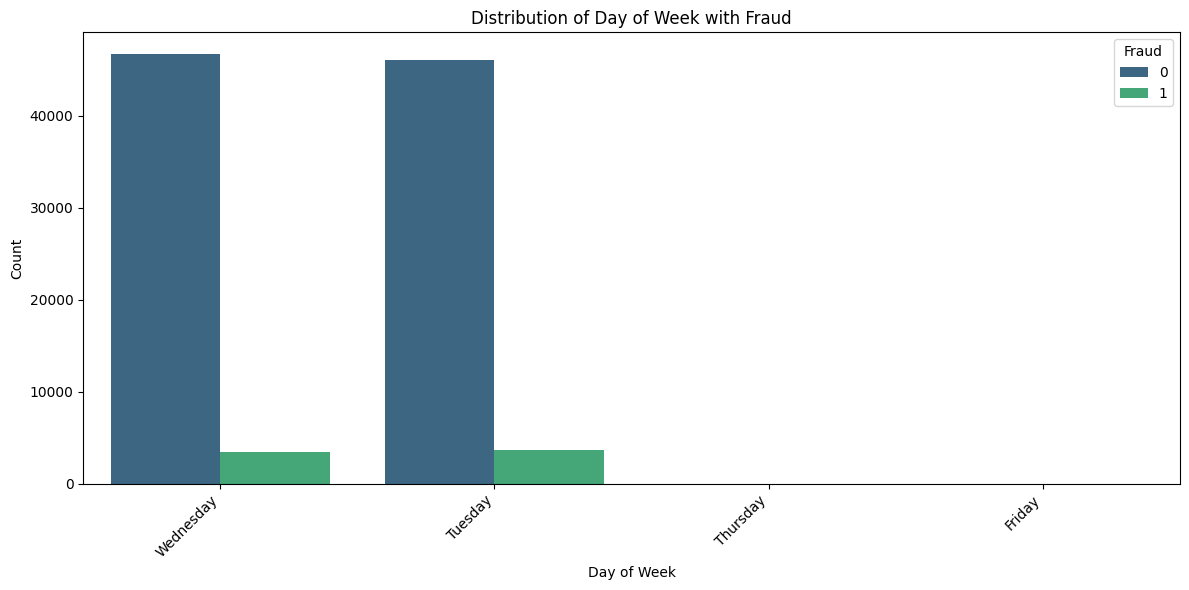

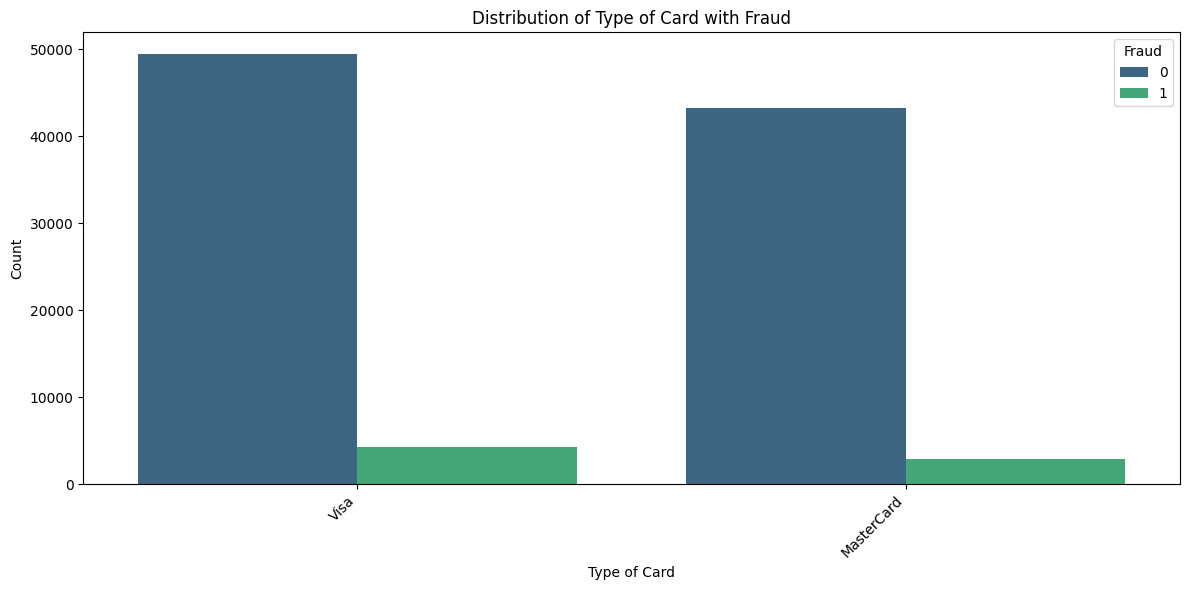

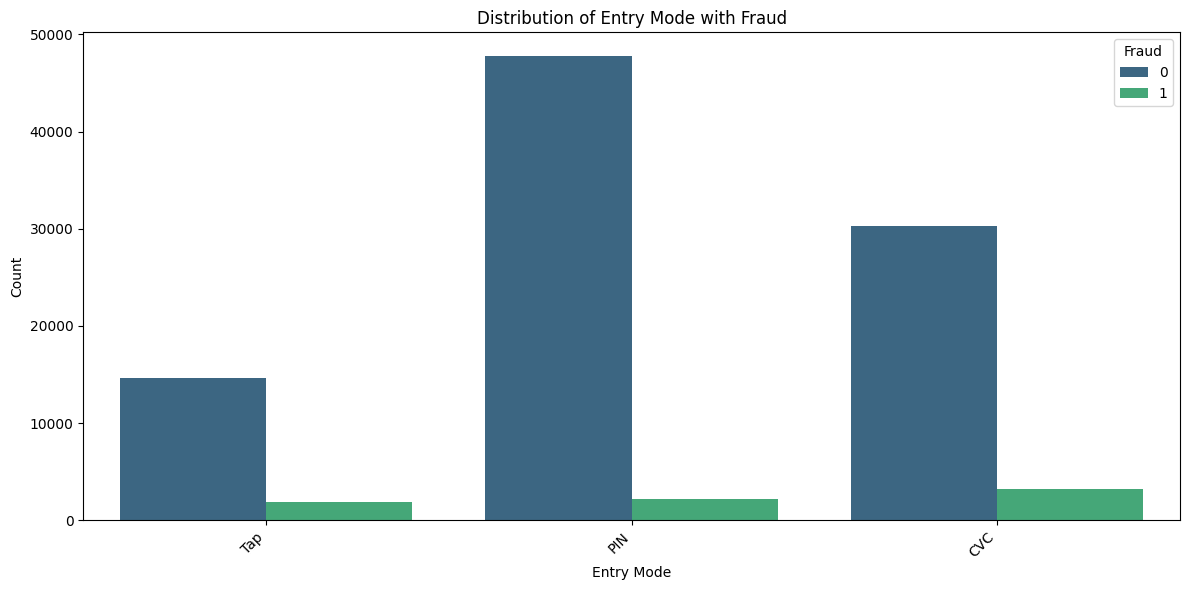

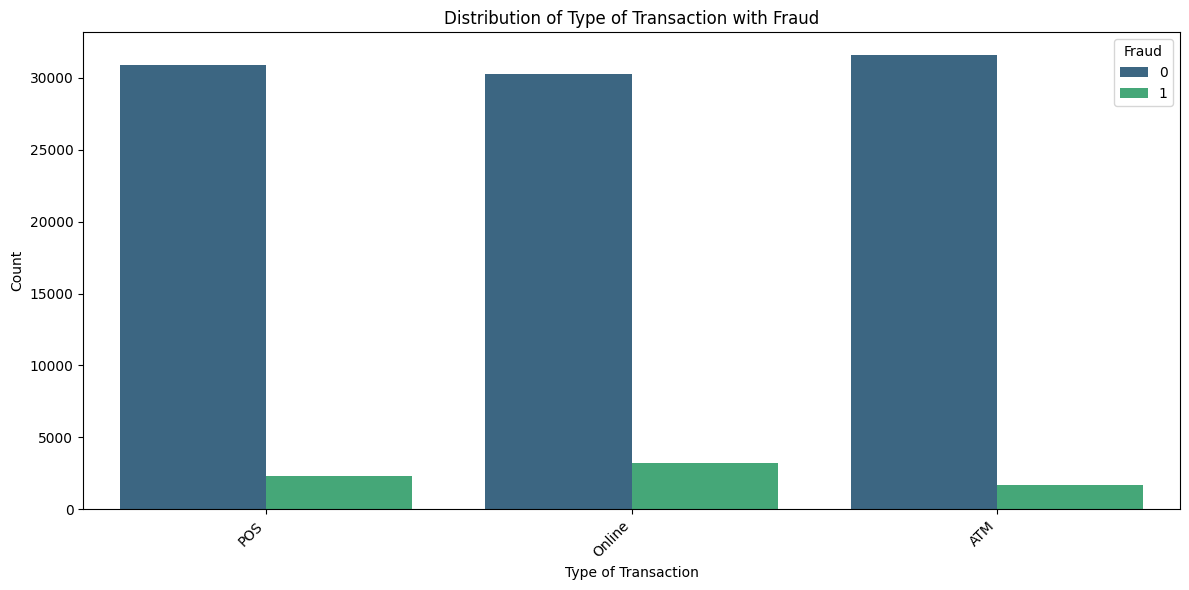

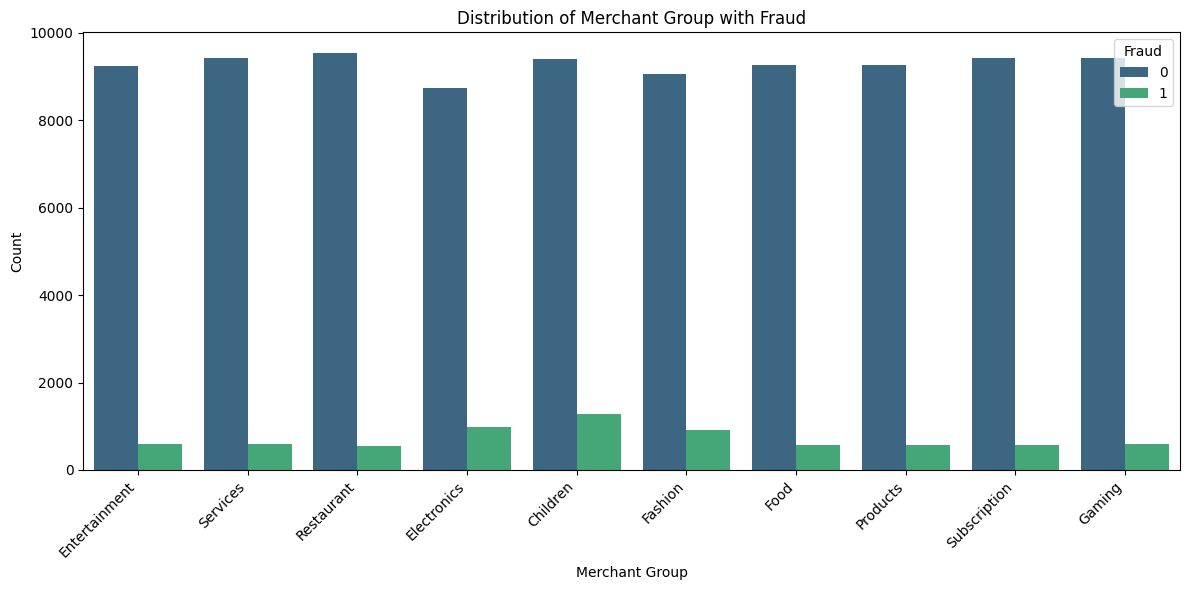

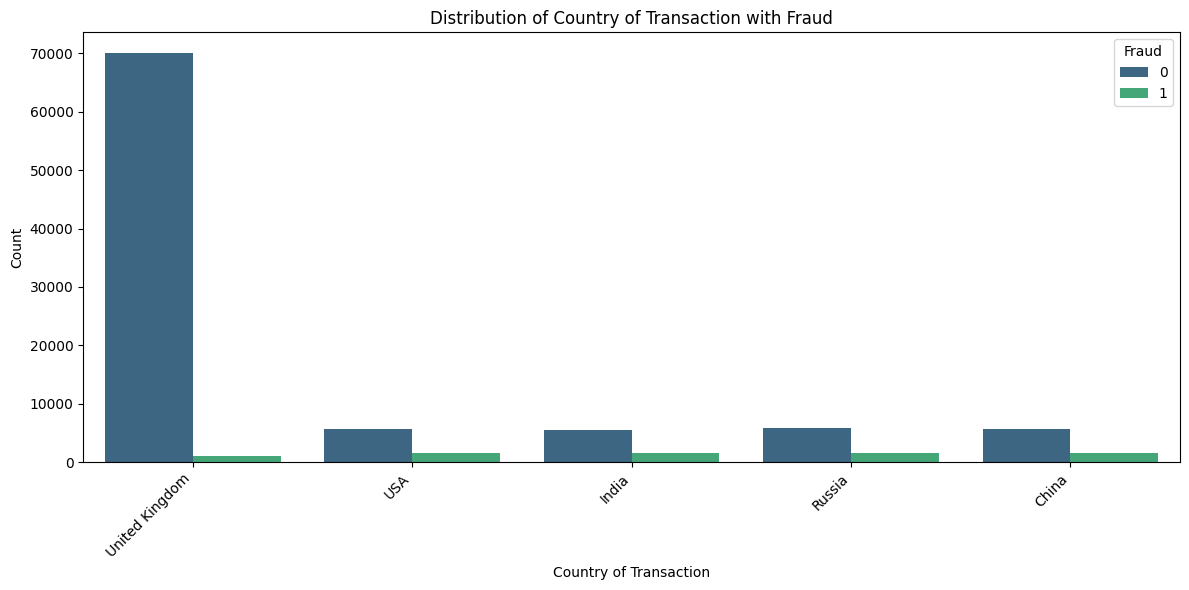

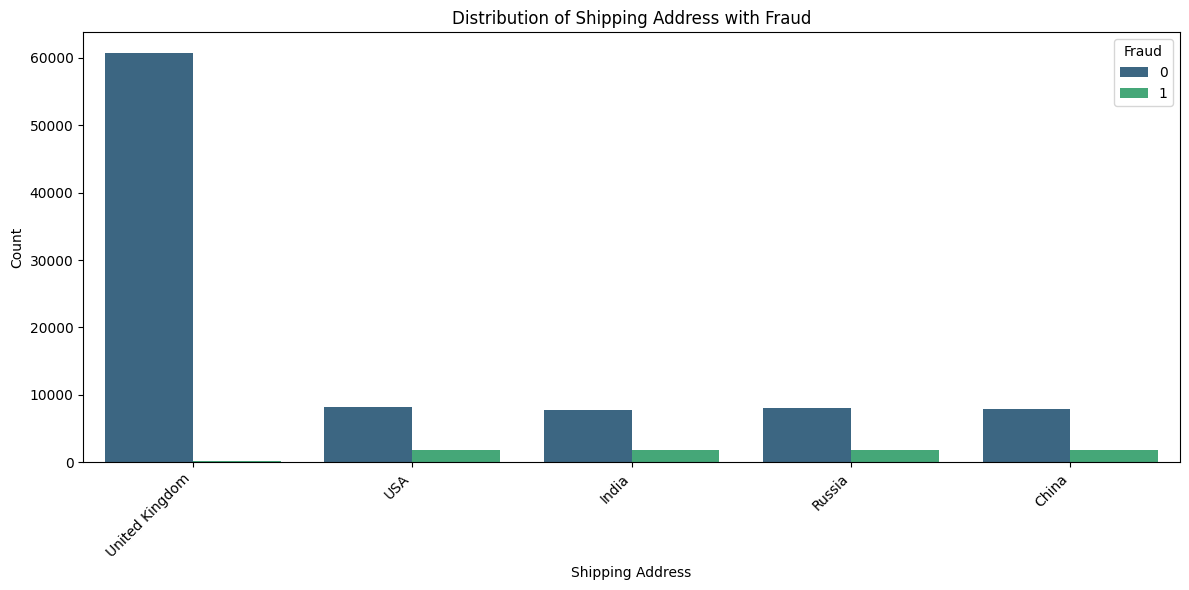

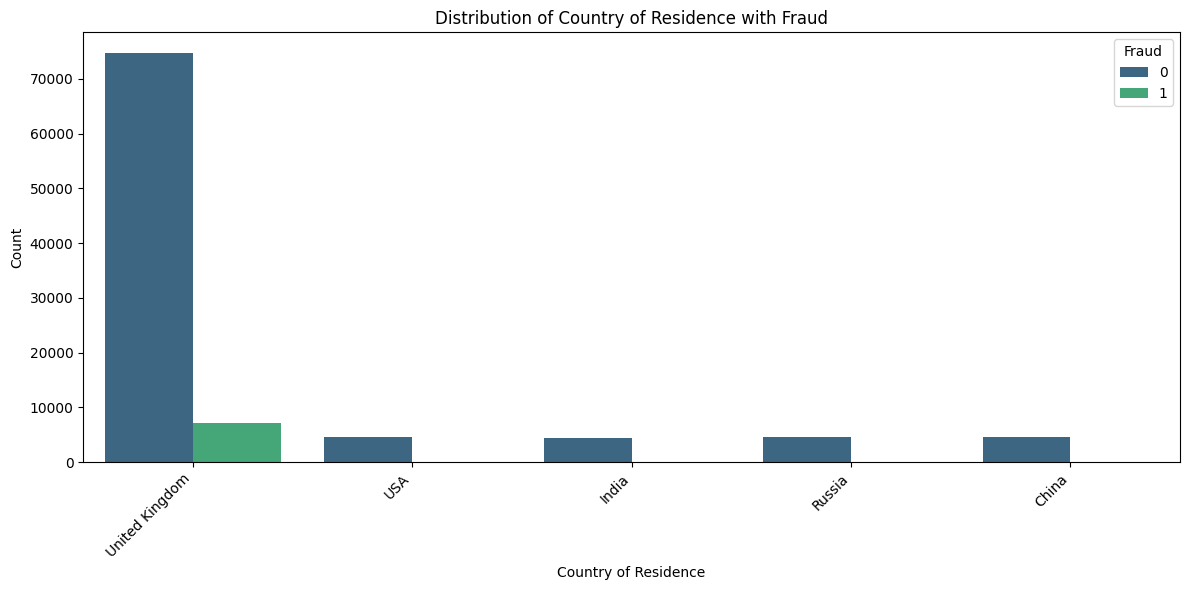

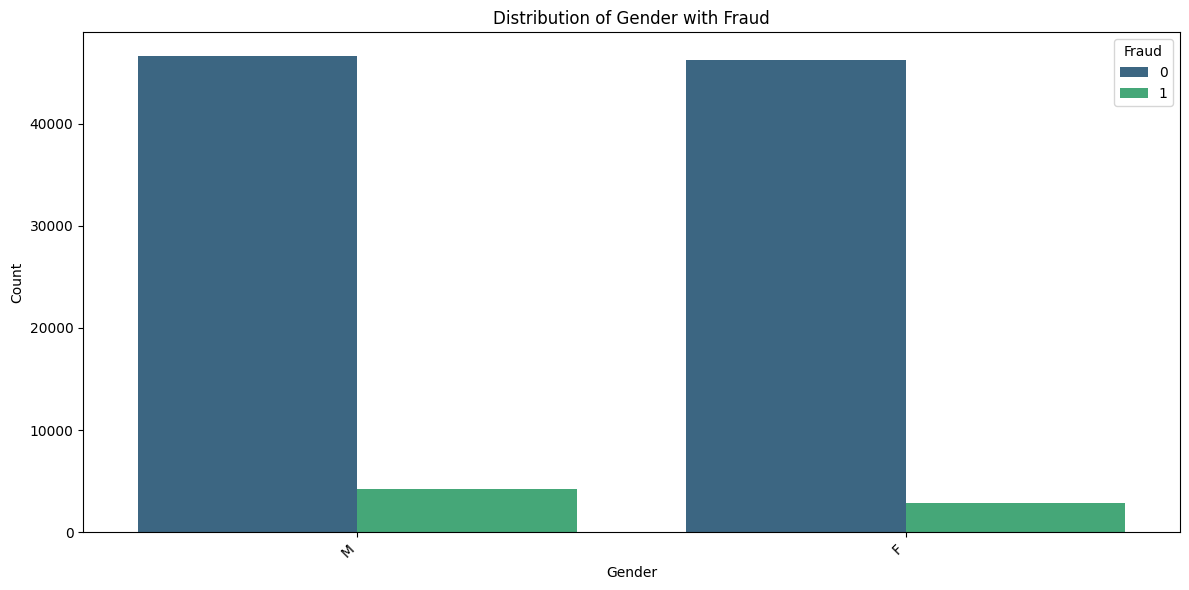

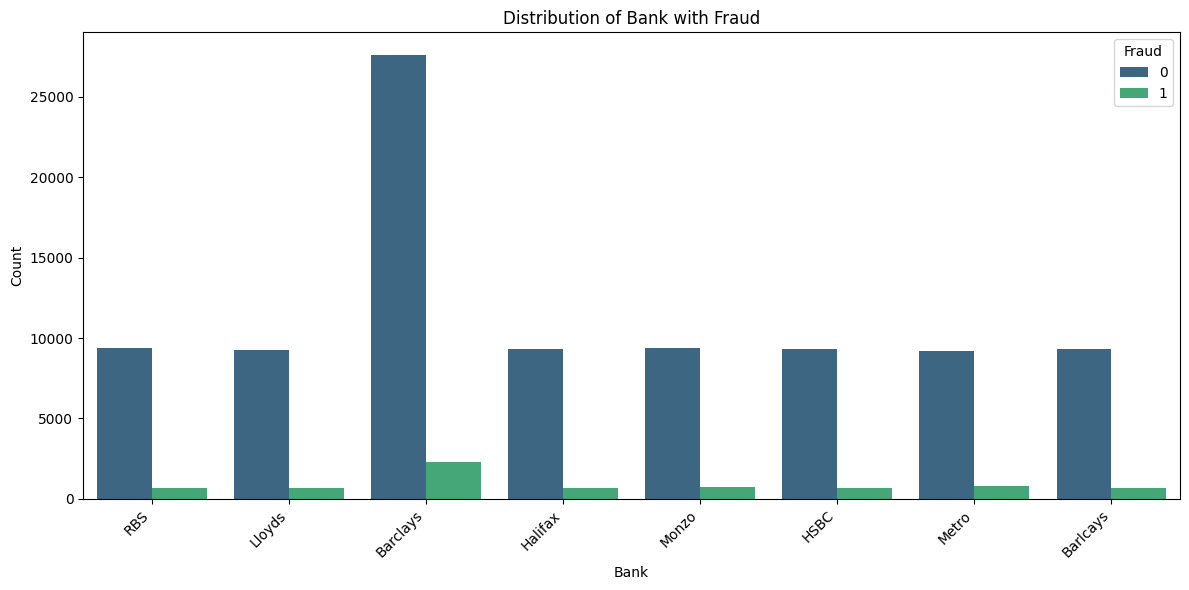

In [58]:
for col in categorical_columns:
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, x=col, hue='Fraud', palette='viridis')
    plt.title(f'Distribution of {col} with Fraud')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [60]:
# save this cleaned data
df.to_csv('cleaned_data.csv', index=False)

# Data Transformation and Model Trainning

In [70]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LearningCurveDisplay, ShuffleSplit

In [64]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore',drop='first'), categorical_columns),
        ('num', StandardScaler(), numerical_columns)
    ])


In [94]:
algorithms = [
     RandomForestClassifier(
      n_estimators=100,
      max_depth=10,
      n_jobs=-1,
      random_state=42,
      class_weight='balanced'
   ),

    XGBClassifier(),
    LGBMClassifier(
    class_weight='balanced',
    random_state=42
)
]

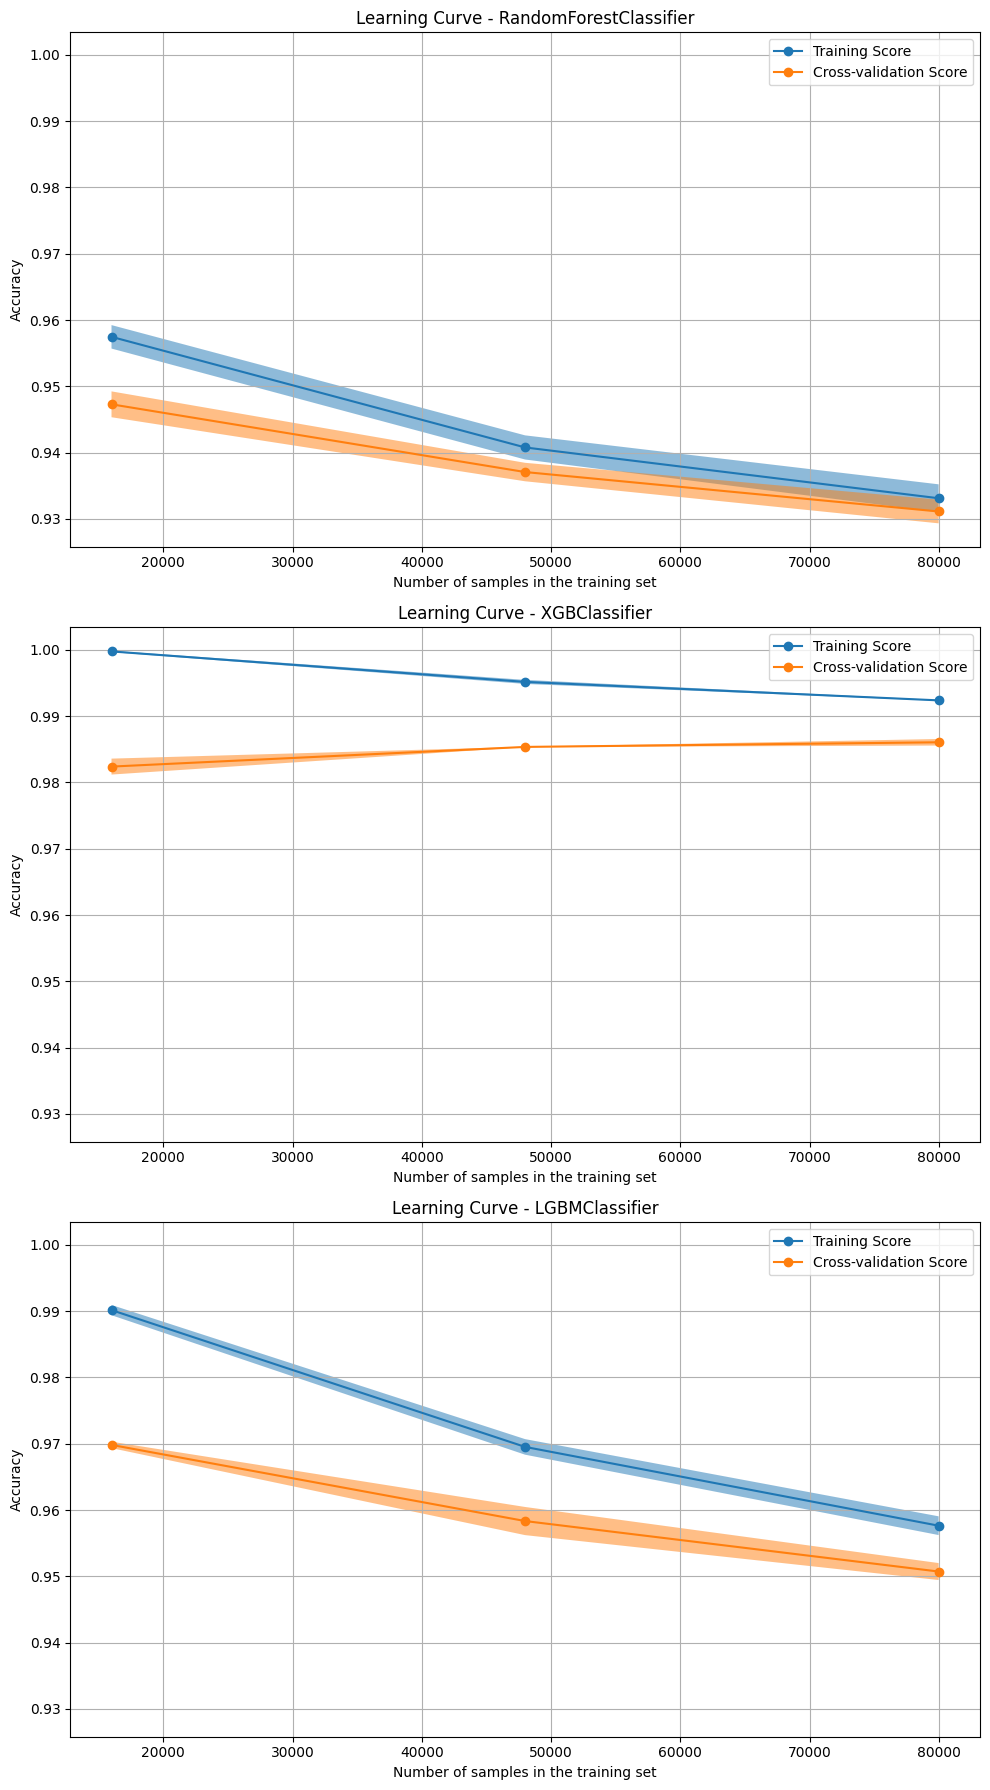

In [95]:
num_algorithms = len(algorithms)

fig, axes = plt.subplots(
    nrows=num_algorithms,
    ncols=1,
    figsize=(10, 6 * num_algorithms),
    sharey=True
)

# If only one algorithm, convert axes to list
if num_algorithms == 1:
    axes = [axes]

common_params = {
    "X": X,
    "y": Y,
    "train_sizes": np.linspace(0.2, 1.0, 3),
    "cv": ShuffleSplit(n_splits=3, test_size=0.2, random_state=0),
    "score_type": "both",
    "n_jobs": -1,
    "line_kw": {"marker": "o"},
    "std_display_style": "fill_between",
    "score_name": "Accuracy",
}

for ax, model_algo in zip(axes, algorithms):

    pipeline_estimator = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model_algo)
    ])

    LearningCurveDisplay.from_estimator(
        pipeline_estimator,
        **common_params,
        ax=ax
    )

    handles, labels = ax.get_legend_handles_labels()

    ax.legend(
        handles[:2],
        ["Training Score", "Cross-validation Score"]
    )

    ax.set_title(
        f"Learning Curve - {model_algo.__class__.__name__}"
    )

    ax.grid(True)

plt.tight_layout()
plt.show()

### Model Training and ROC-AUC Curve Analysis

In [96]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (79981, 13)
X_test shape: (19996, 13)
y_train shape: (79981,)
y_test shape: (19996,)



Training and evaluating RandomForestClassifier...

Training and evaluating XGBClassifier...

Training and evaluating LGBMClassifier...
[LightGBM] [Info] Number of positive: 5754, number of negative: 74227
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011419 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 605
[LightGBM] [Info] Number of data points in the train set: 79981, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


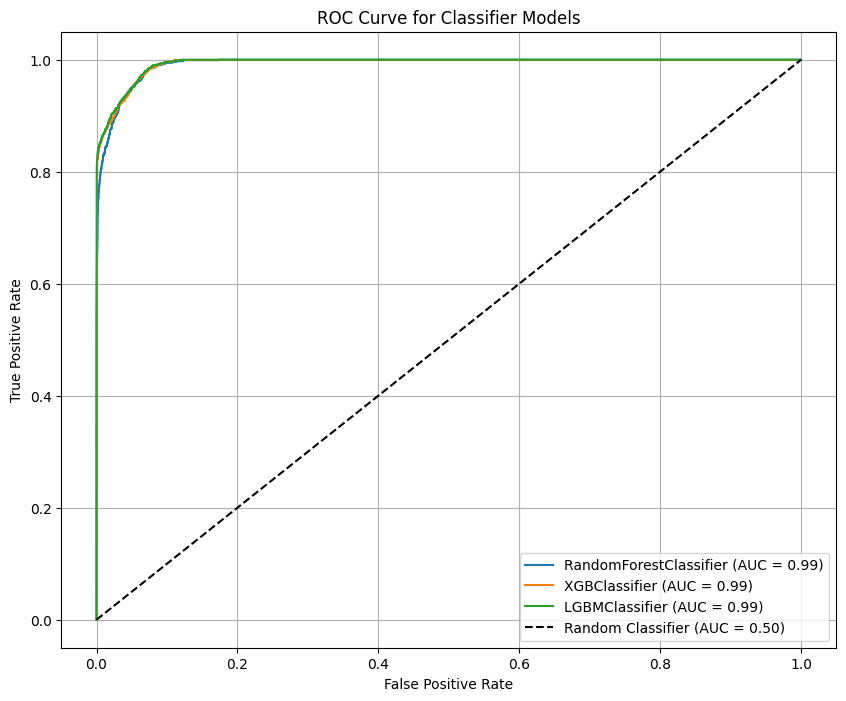

In [97]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(10, 8))

# Dictionary to store results for threshold analysis
model_results = {}

for model_algo in algorithms:
    model_name = model_algo.__class__.__name__
    print(f"\nTraining and evaluating {model_name}...")

    # Create a pipeline with preprocessing and the classifier
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model_algo)
    ])

    # Train the model
    pipeline.fit(X_train, y_train)

    # Predict probabilities for the positive class
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    auc_score = roc_auc_score(y_test, y_pred_proba)

    # Plot ROC curve
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.2f})')

    # Store results for potential threshold analysis
    model_results[model_name] = {'fpr': fpr, 'tpr': tpr, 'thresholds': thresholds, 'auc': auc_score}

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)') # Random classifier
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Classifier Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Interpreting ROC Curves and Determining Thresholds

The **Receiver Operating Characteristic (ROC) curve** is a powerful tool for evaluating the performance of classification models, especially when dealing with imbalanced datasets. It illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied.

*   **True Positive Rate (TPR)**: Also known as recall or sensitivity, it's the proportion of actual positive cases that are correctly identified as positive. (TP / (TP + FN))
*   **False Positive Rate (FPR)**: The proportion of actual negative cases that are incorrectly identified as positive. (FP / (FP + TN))

**Interpreting the Curves:**
*   A curve that hugs the top-left corner indicates a high TPR and a low FPR, signifying a good model.
*   A diagonal line from the bottom-left to the top-right represents a random classifier (AUC = 0.5).
*   The further the curve is from the diagonal line, the better the model's performance.

**Area Under the Curve (AUC):**
*   The **Area Under the ROC Curve (AUC)** summarizes the entire ROC curve into a single value.
*   AUC ranges from 0 to 1.
*   An AUC of 1 means a perfect classifier.
*   An AUC of 0.5 means the classifier is as good as random guessing.
*   Generally, a higher AUC indicates a better model.


After examining the ROC curves, you can decide which model performs best for your specific needs and then use one of these methods to select a suitable threshold.

### Detailed Analysis for LightGBM (LGBMClassifier)

### Precision-Recall Trade-off for LightGBM

In [103]:
lgbm_model = algorithms[2] # Assuming LGBMClassifier is the third model in the list
lgbm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', lgbm_model)
])

# Train the LGBM model
lgbm_pipeline.fit(X_train, y_train)

# Get probabilities for the positive class
y_pred_proba_lgbm = lgbm_pipeline.predict_proba(X_test)[:, 1]


[LightGBM] [Info] Number of positive: 5754, number of negative: 74227
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011237 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 605
[LightGBM] [Info] Number of data points in the train set: 79981, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


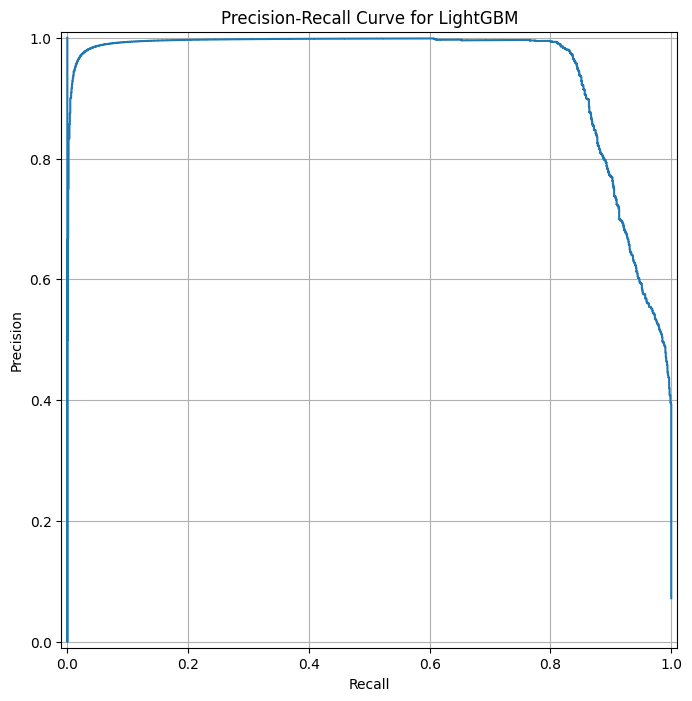


--- Precision, Recall, F1-Score for various thresholds ---
Threshold: 0.01 | Precision: 0.3352 | Recall: 1.0000 | F1-Score: 0.5021
Threshold: 0.12 | Precision: 0.4356 | Recall: 0.9965 | F1-Score: 0.6062
Threshold: 0.23 | Precision: 0.4865 | Recall: 0.9903 | F1-Score: 0.6525
Threshold: 0.34 | Precision: 0.5268 | Recall: 0.9771 | F1-Score: 0.6845
Threshold: 0.45 | Precision: 0.5698 | Recall: 0.9569 | F1-Score: 0.7142
Threshold: 0.55 | Precision: 0.6438 | Recall: 0.9339 | F1-Score: 0.7622
Threshold: 0.66 | Precision: 0.7402 | Recall: 0.9054 | F1-Score: 0.8145
Threshold: 0.77 | Precision: 0.8773 | Recall: 0.8651 | F1-Score: 0.8711
Threshold: 0.88 | Precision: 0.9882 | Recall: 0.8171 | F1-Score: 0.8946
Threshold: 0.99 | Precision: 0.9967 | Recall: 0.6398 | F1-Score: 0.7793

By observing this table and the Precision-Recall curve, you can select a threshold that provides the desired balance between precision and recall for your application. Increasing the threshold generally increases precis

In [104]:
from sklearn.metrics import precision_recall_curve, auc, PrecisionRecallDisplay, precision_score, recall_score, f1_score

# Calculate Precision-Recall curve
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_pred_proba_lgbm)

# Plot Precision-Recall curve
fig, ax = plt.subplots(figsize=(10, 8))
pr_display = PrecisionRecallDisplay(precision=precision, recall=recall).plot(ax=ax)
ax.set_title('Precision-Recall Curve for LightGBM')
ax.grid(True)
plt.show()

print("\n--- Precision, Recall, F1-Score for various thresholds ---")
# Evaluate metrics at specific thresholds to demonstrate trade-off
sample_thresholds = np.linspace(0.01, 0.99, 10) # 10 thresholds from 0.01 to 0.99

for thr in sample_thresholds:
    y_pred_at_thr = (y_pred_proba_lgbm >= thr).astype(int)
    prec = precision_score(y_test, y_pred_at_thr)
    rec = recall_score(y_test, y_pred_at_thr)
    f1 = f1_score(y_test, y_pred_at_thr)
    print(f"Threshold: {thr:.2f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1-Score: {f1:.4f}")

print("\nBy observing this table and the Precision-Recall curve, you can select a threshold that provides the desired balance between precision and recall for your application. Increasing the threshold generally increases precision at the cost of recall.")

### Interpreting LightGBM's Performance

#### Classification Report

The **Classification Report** provides key metrics for evaluating the performance of the LightGBM model at the calculated optimal threshold. For fraud detection, pay close attention to the `1` class (Fraud):

*   **Precision (for Fraud):** This tells us, out of all transactions the model *predicted* as fraudulent, how many actually were fraudulent. A high precision minimizes false alarms.
*   **Recall (for Fraud):** This tells us, out of all *actual* fraudulent transactions, how many the model correctly identified. A high recall minimizes missed fraud cases (False Negatives).
*   **F1-Score (for Fraud):** This is the harmonic mean of precision and recall, providing a balanced measure of the model's accuracy.
*   **Support:** The number of actual occurrences of each class in the `y_test` dataset.

#### Confusion Matrix

The **Confusion Matrix** provides a detailed breakdown of the model's predictions:

*   **True Negative (Top-Left):** Correctly predicted non-fraudulent transactions.
*   **False Positive (Top-Right):** Non-fraudulent transactions incorrectly predicted as fraudulent (Type I error - a 'false alarm').
*   **False Negative (Bottom-Left):** Fraudulent transactions incorrectly predicted as non-fraudulent (Type II error - a 'missed fraud'). This is often the most critical error in fraud detection.
*   **True Positive (Bottom-Right):** Correctly predicted fraudulent transactions.

By analyzing these metrics, especially the trade-off between False Positives and False Negatives, you can determine if the optimal threshold chosen by Youden's J statistic aligns with the specific business requirements and costs associated with different types of errors in your fraud detection system.

Optimal Threshold is 0.77 , balanced and best, we may also go with 0.88 as per buisness requirement

Using Optimal Threshold for LGBM: 0.8800

Classification Report for LGBMClassifier:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     18558
           1       0.99      0.82      0.89      1438

    accuracy                           0.99     19996
   macro avg       0.99      0.91      0.94     19996
weighted avg       0.99      0.99      0.99     19996



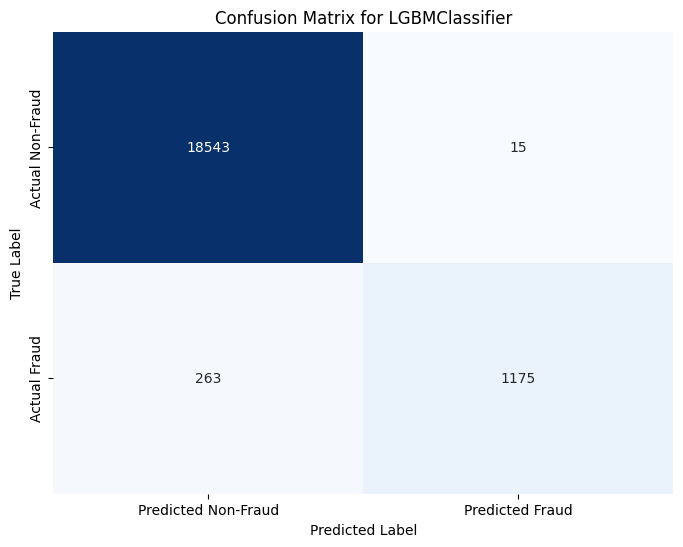

In [108]:
optimal_threshold_lgbm = 0.88

y_pred_lgbm = (y_pred_proba_lgbm >= optimal_threshold_lgbm).astype(int)

print(f"Using Optimal Threshold for LGBM: {optimal_threshold_lgbm:.4f}")

# Print Classification Report
print("\nClassification Report for LGBMClassifier:")
print(classification_report(y_test, y_pred_lgbm))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lgbm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Non-Fraud', 'Predicted Fraud'],
            yticklabels=['Actual Non-Fraud', 'Actual Fraud'])
plt.title('Confusion Matrix for LGBMClassifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
